# Tile coding RL agent

In [1]:
import sys
sys.path.insert(0, "../")

from math import radians
from random import uniform
import pickle

from tqdm.notebook import tqdm
import numpy as np
import xarray as xr
import xarray.ufuncs as xrf
import matplotlib.pyplot as plt

from cw.filters import smooth_signal

from pole.cpp import Environment, TileCodingAgent

In [2]:
env = Environment(0.500, 0.100, radians(30), radians(30))

In [3]:
config = 1
# tilings, n_actions, tile_size, n_episodes, min/max_action
configs = [
    (1, 5, [radians(4.44), 0.244, 0.02], 1000, 0.3),
    (20, 5, [radians(4.44), 0.244, 0.02], 1000, 0.3),
    (20, 5, [radians(10), 0.5, 0.08], 1000, 0.3),        # 10 000
    (40, 11, [radians(20), 1, 0.08], 20000, 0.3),         # 20 000
    (100, 5, [radians(60), 10, 0.1], 1000, 0.3),         #  1 000
    (100, 5, [radians(20), 10, 0.1], 5000, 0.18),         #  1 000
]

agent = TileCodingAgent(
    env,
    center=[0, 0, 0],
    tile_size=configs[config][2],
    tilings=configs[config][0],
    default_weight=0.0,
    random_offsets=True,
    min_action=-configs[config][4],
    max_action=configs[config][4],
    n_actions=configs[config][1],
    epsilon=0.9,
    gamma=0.9,
    alpha=0.2,
    vc_min_theta=radians(-30),
    vc_max_theta=radians(30),
    vc_n_theta=512,
    vc_min_theta_dot=-0.1,
    vc_max_theta_dot=0.1,
    vc_n_theta_dot=512,
)

In [2]:
env = Environment(0.500, 0.100, radians(181), radians(181))
agent = TileCodingAgent(
    env,
    center=[0, 0, 0],
    tile_size=[radians(20), 10, 0.1],
    tilings=100,
    default_weight=0.0,
    random_offsets=True,
    min_action=-0.3,
    max_action=0.3,
    n_actions=5,
    epsilon=0.7,
    gamma=0.9,
    alpha=0.2,
    vc_min_theta=radians(-180),
    vc_max_theta=radians(180),
    vc_n_theta=512,
    vc_min_theta_dot=-30,
    vc_max_theta_dot=30,
    vc_n_theta_dot=512,
)

In [2]:
# Working
env = Environment(0.500, 0.100, radians(30), radians(30))
agent = TileCodingAgent(
    env,
    center=[0, 0, 0],
    tile_size=[radians(4.44), 0.244, 0.02],
    tilings=10,
    default_weight=0.0,
    random_offsets=True,
    min_action=-0.3,
    max_action=0.3,
    n_actions=5,
    epsilon=0.7,
    gamma=0.9,
    alpha=0.2,
    vc_min_theta=radians(-30),
    vc_max_theta=radians(30),
    vc_n_theta=512,
    vc_min_theta_dot=-1,
    vc_max_theta_dot=1,
    vc_n_theta_dot=512,
)

In [11]:
reward_sum = []
avg_steps = 0
n_episodes = 10000

for episode_idx in tqdm(range(n_episodes)):
    env.reset()
    env.theta = radians(uniform(-30, 30))
    env.theta_dot = uniform(-1, 1)
    avg_steps += agent.run_episode(1000)
    reward_sum.append(agent.get_reward_sum())

avg_steps /= n_episodes
    
data = agent.get_data()

In [12]:
avg_steps

903.13

In [13]:
agent.epsilon = 1
env.reset()
env.theta = radians(5)
env.theta_dot = radians(0)
agent.run_episode(1000)
data = agent.get_data()
data

1000

<xarray.Dataset>
Dimensions:    (time: 1000)
Coordinates:
  * time       (time) float64 0.001 0.002 0.003 0.004 ... 0.997 0.998 0.999 1.0
Data variables:
    action     (time) float64 -0.3 -0.3 -0.3 -0.3 -0.3 ... 0.3 0.3 -0.3 0.3 -0.3
    delta_v    (time) float64 -0.003732 0.007879 ... 0.0003883 0.0001108
    reward     (time) float64 0.695 0.696 0.6976 0.6998 ... 0.9974 0.9983 0.9985
    theta      (time) float64 0.0871 0.08676 0.08626 ... -0.0004424 -0.0003836
    theta_dot  (time) float64 -0.1672 -0.3344 -0.5016 ... 0.05896 0.2389 0.0588

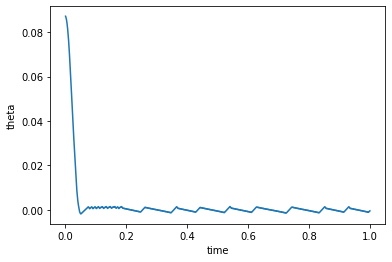

In [14]:
data.theta.plot()

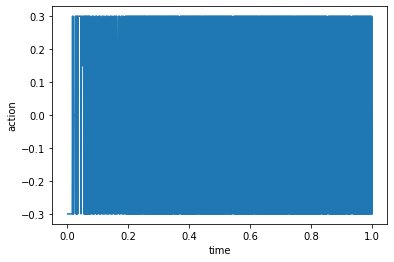

In [15]:
data.action.plot()

<Figure size 864x576 with 0 Axes>

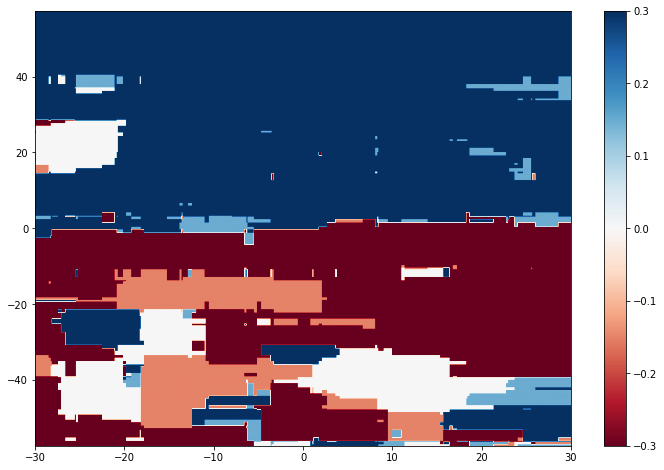

In [16]:
table = agent.get_greedy_action_table().T
plt.figure(figsize=(12, 8))
plt.imshow(table, cmap='RdBu', aspect="auto", extent=[
    min(np.degrees(agent.thetas)), max(np.degrees(agent.thetas)),
    min(np.degrees(agent.theta_dots)), max(np.degrees(agent.theta_dots)),
])
plt.colorbar()

<Figure size 864x576 with 0 Axes>

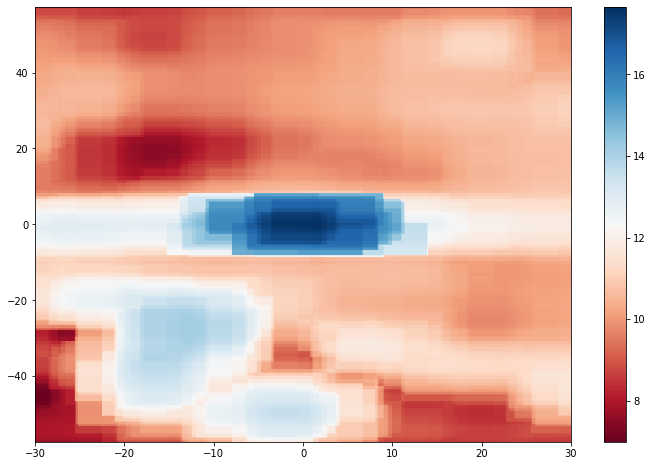

In [17]:
table = agent.get_counts().T
plt.figure(figsize=(12, 8))
plt.imshow(np.log(table), cmap='RdBu', aspect="auto", extent=[
    min(np.degrees(agent.thetas)), max(np.degrees(agent.thetas)),
    min(np.degrees(agent.theta_dots)), max(np.degrees(agent.theta_dots)),
])
plt.colorbar()